# Maxwell-Boltzmann and activation energy

**Chemistry HL - Reactivity 2.2**

Raising the temperature barely moves the peak of the distribution. What it does
is stretch the **tail** past $E_a$ - and that is what controls the rate.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

K_B = 1.380649e-23   # J K^-1
N_A = 6.02214076e23  # mol^-1
MASS = 0.028 / N_A   # kg per molecule (nitrogen)

EA_KJ = 50.0
EA_J = EA_KJ * 1000 / N_A
V_EA = np.sqrt(2 * EA_J / MASS)   # speed carrying kinetic energy Ea

print(f"Molecules need {V_EA:.0f} m/s to clear a {EA_KJ:.0f} kJ/mol barrier")

Molecules need 1890 m/s to clear a 50 kJ/mol barrier


In [2]:
def distribution(v, T):
    a = MASS / (2 * K_B * T)
    return 4 * np.pi * v**2 * (a / np.pi) ** 1.5 * np.exp(-a * v**2)


def fraction_above_ea(T):
    frac, _ = integrate.quad(distribution, V_EA, np.inf, args=(T,))
    return frac

## The curves

Shaded = molecules with enough energy to react.

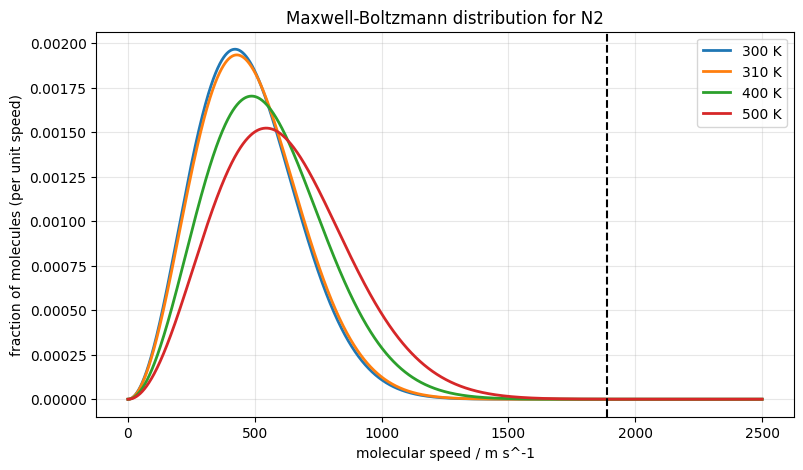

In [3]:
v = np.linspace(0, 2500, 1500)

fig, ax = plt.subplots(figsize=(9, 5))
for T in (300, 310, 400, 500):
    f = distribution(v, T)
    ax.plot(v, f, lw=2, label=f"{T} K")
    ax.fill_between(v, f, where=(v >= V_EA), alpha=0.25)

ax.axvline(V_EA, color="black", ls="--", lw=1.5)
ax.set_xlabel("molecular speed / m s^-1")
ax.set_ylabel("fraction of molecules (per unit speed)")
ax.set_title("Maxwell-Boltzmann distribution for N2")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## The 10 K question

This is the number behind 'rates roughly double for a 10 K rise'.

In [4]:
f300, f310 = fraction_above_ea(300), fraction_above_ea(310)
print(f"Fraction above Ea at 300 K: {f300:.3e}")
print(f"Fraction above Ea at 310 K: {f310:.3e}")
print(f"Ratio for a 10 K rise:      {f310 / f300:.2f}x")

Fraction above Ea at 300 K: 1.026e-08
Fraction above Ea at 310 K: 1.932e-08
Ratio for a 10 K rise:      1.88x


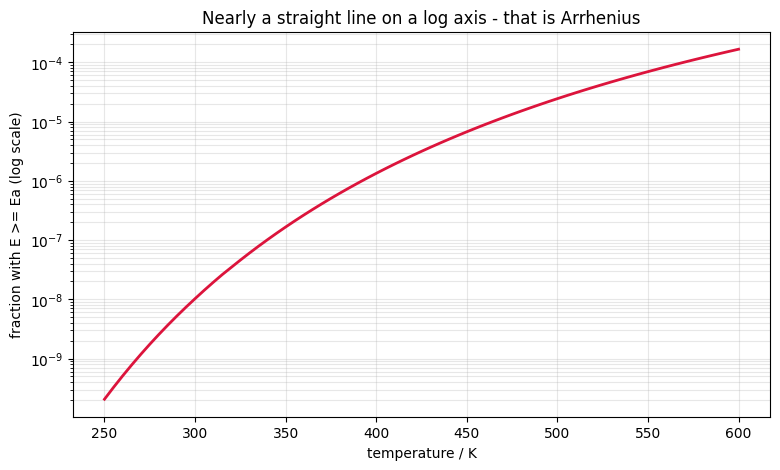

In [5]:
temps = np.arange(250, 601, 5)
fractions = np.array([fraction_above_ea(T) for T in temps])

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(temps, fractions, lw=2, color="crimson")
ax.set_xlabel("temperature / K")
ax.set_ylabel("fraction with E >= Ea (log scale)")
ax.set_title("Nearly a straight line on a log axis - that is Arrhenius")
ax.grid(alpha=0.3, which="both")
plt.show()

## Try changing

- `EA_KJ` - a higher barrier makes temperature sensitivity much stronger. Drop
  it to 25 and the 10 K ratio falls to about 1.4x. This is also why a catalyst
  (lower $E_a$) speeds things up so much.
- `MASS` - compare hydrogen (0.002) against nitrogen at the same temperature.